# Credit Risk Scoring System

## Objective:
To build a Machine Learning model that predicts whether a loan applicant is likely to default or repay the loan.

## Business Problem:
Banks need to evaluate credit risk before approving loans to reduce financial losses.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/credit_risk_scoring_dataset.csv")
df.head()

,Income,Credit_History,Loan_Amount,Employment_Type,Age,Existing_Loans,Default
0,109585,0,70456,Salaried,60,2,1
1,23803,1,235905,Business,36,4,1
2,84249,1,419398,Self-Employed,56,0,0
3,61384,0,425104,Self-Employed,21,0,1
4,147768,1,65600,Salaried,53,5,0


In [3]:
df.shape


(200, 7)

In [4]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Income           200 non-null    int64 
 1   Credit_History   200 non-null    int64 
 2   Loan_Amount      200 non-null    int64 
 3   Employment_Type  200 non-null    object
 4   Age              200 non-null    int64 
 5   Existing_Loans   200 non-null    int64 
 6   Default          200 non-null    int64 
dtypes: int64(6), object(1)
memory usage: 11.1+ KB


In [5]:
df.describe()

,Income,Credit_History,Loan_Amount,Age,Existing_Loans,Default
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,89761.095000,0.460000,266562.145000,38.985000,2.575000,0.595000
std,36074.070721,0.499648,128034.527122,12.243131,1.772026,0.492124
min,20084.000000,0.000000,52429.000000,21.000000,0.000000,0.000000
25%,59333.250000,0.000000,157832.500000,28.000000,1.000000,0.000000
50%,91056.000000,0.000000,255969.000000,39.000000,3.000000,1.000000
75%,120762.500000,1.000000,371760.500000,50.000000,4.000000,1.000000
max,149687.000000,1.000000,496311.000000,60.000000,5.000000,1.000000


In [6]:
df.isnull().sum()

Income             0
Credit_History     0
Loan_Amount        0
Employment_Type    0
Age                0
Existing_Loans     0
Default            0
dtype: int64

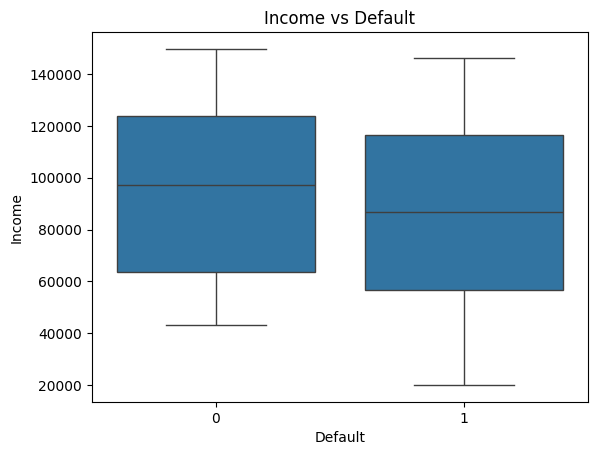

In [7]:
sns.boxplot(x='Default', y='Income', data=df)
plt.title("Income vs Default")
plt.show()

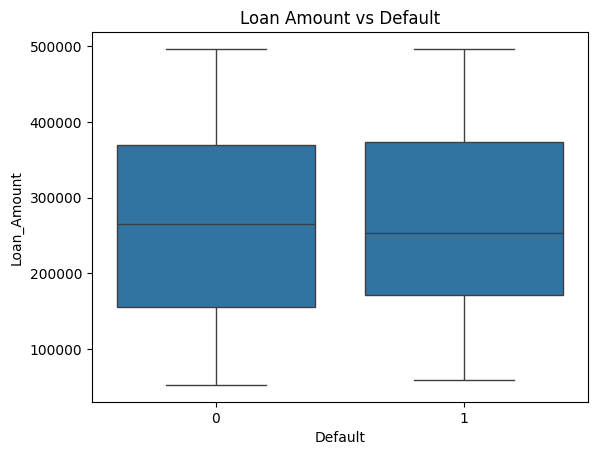

In [8]:
sns.boxplot(x='Default', y='Loan_Amount', data=df)
plt.title("Loan Amount vs Default")
plt.show()

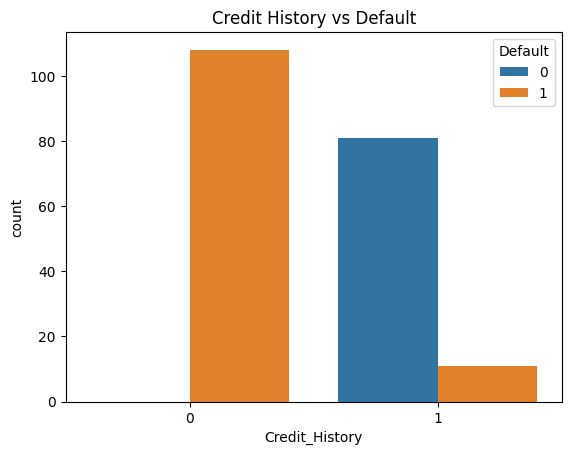

In [9]:
sns.countplot(x='Credit_History', hue='Default', data=df)
plt.title("Credit History vs Default")
plt.show()

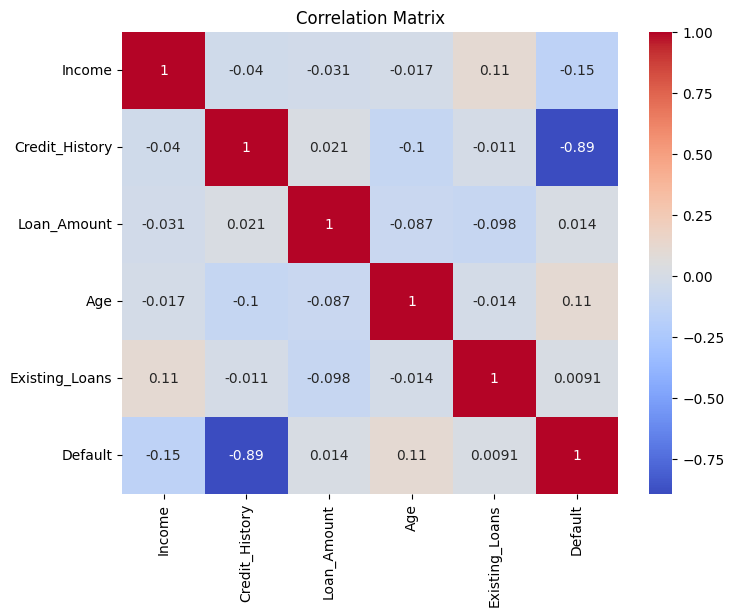

In [11]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

In [12]:
from sklearn.preprocessing import LabelEncoder

for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

In [13]:
from sklearn.model_selection import train_test_split

X = df.drop("Default", axis=1)
y = df["Default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [15]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.975

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.98        21
           1       1.00      0.95      0.97        19

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.97        40
weighted avg       0.98      0.97      0.97        40



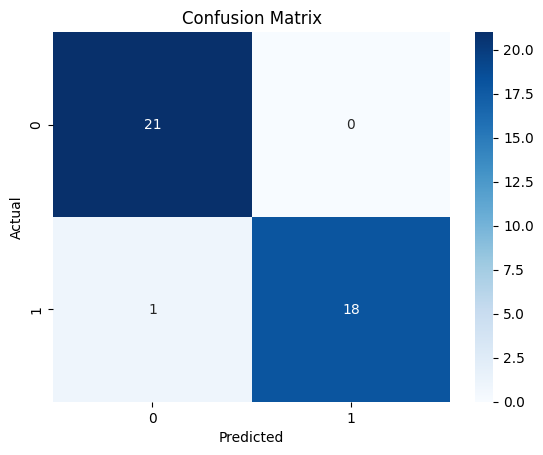

In [16]:
sns.heatmap(confusion_matrix(y_test, y_pred), 
            annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()